# 01 — Eksplorasi Data

Notebook ini menganalisis dataset dengan **3 fitur**: `accel_stddev`, `gyro_stddev`, dan `bpm_filled`.

**Prasyarat:** Dataset harus sudah tersedia di `dataset/dataset.csv`.
Jalankan `src/collect_participants.py` terlebih dahulu untuk mengumpulkan data dari ESP32.

**Alur pengumpulan data:**
1. `collect_participants.py` — operator input ID peserta + pilih label aktivitas manual
2. ESP32 kirim data sensor (tanpa label) via MQTT
3. `collect_participants.py` beri label sesuai pilihan operator → simpan ke `dataset/dataset.csv`
4. Notebook ini membaca `dataset/dataset.csv` untuk eksplorasi


In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import DATASET_PATH, CLASSES, FEATURES, TARGET
from utils  import load_and_clean_dataset, impute_bpm, class_distribution, get_logger

logger = get_logger('notebook_01')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (13, 5)
COLORS = ['#4C72B0', '#DD8452', '#55A868']
print('Library siap. Fitur:', FEATURES)

Library siap. Fitur: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Muat & Bersihkan Dataset

In [2]:
df_raw = load_and_clean_dataset(DATASET_PATH)
print(f'Shape raw: {df_raw.shape}')
print(f'Kolom    : {df_raw.columns.tolist()}')
print(f'\nDistribusi kelas:\n{df_raw[TARGET].value_counts()}')
df_raw.head(8)

Shape raw: (13410, 7)
Kolom    : ['accel_stddev', 'gyro_stddev', 'bpm', 'activity', 'participant_id', 'participant_no', 'received_at']

Distribusi kelas:
activity
BERLARI     4501
BERJALAN    4464
DUDUK       4445
Name: count, dtype: int64


,accel_stddev,gyro_stddev,bpm,activity,participant_id,participant_no,received_at
0,0.012984,19.6526,0,DUDUK,PSR_001,1,2026-05-02T10:35:27.440329
1,0.033670,30.9924,0,DUDUK,PSR_001,1,2026-05-02T10:35:29.436682
2,0.024653,28.2483,0,DUDUK,PSR_001,1,2026-05-02T10:35:31.437199
3,0.011243,13.3790,0,DUDUK,PSR_001,1,2026-05-02T10:35:33.438319
4,0.012932,5.9294,0,DUDUK,PSR_001,1,2026-05-02T10:35:35.443163
5,0.038141,44.5737,49,DUDUK,PSR_001,1,2026-05-02T10:35:37.448227
6,0.007941,11.7289,49,DUDUK,PSR_001,1,2026-05-02T10:35:39.448052
7,0.009864,6.2841,0,DUDUK,PSR_001,1,2026-05-02T10:35:41.448257


## 2. Imputasi BPM = 0

Sensor pulse sering membaca 0 saat sinyal lemah. Nilai 0 diisi dengan median BPM per kelas.

In [3]:
# Tampilkan statistik BPM sebelum imputasi
print('=== BPM sebelum imputasi ===')
print(f'Nilai 0 (tidak terbaca): {(df_raw["bpm"]==0).sum()} dari {len(df_raw)} ({(df_raw["bpm"]==0).mean()*100:.1f}%)')
print(f'Range BPM valid: {df_raw[df_raw["bpm"]>0]["bpm"].min()} – {df_raw[df_raw["bpm"]>0]["bpm"].max()}')

# Imputasi
df, bpm_medians = impute_bpm(df_raw, fit=True)

print('\n=== Setelah imputasi (kolom bpm_filled) ===')
print(df[['accel_stddev','gyro_stddev','bpm','bpm_filled',TARGET]].describe().round(3))

=== BPM sebelum imputasi ===
Nilai 0 (tidak terbaca): 942 dari 13410 (7.0%)
Range BPM valid: 30 – 196
BPM Median per kelas (untuk imputasi):
  DUDUK: 80 bpm
  BERJALAN: 86 bpm
  BERLARI: 130 bpm
  _global: 94 bpm

=== Setelah imputasi (kolom bpm_filled) ===
       accel_stddev  gyro_stddev        bpm  bpm_filled
count     13410.000    13410.000  13410.000   13410.000
mean          0.073       29.196     95.146     101.536
std           0.077       30.116     41.783      33.062
min           0.003        0.018      0.000      30.000
25%           0.011        4.287     75.000      79.000
50%           0.044       19.196     91.000      92.000
75%           0.110       47.396    119.000     121.000
max           0.584      228.007    196.000     196.000


## 3. Distribusi Kelas

=== DISTRIBUSI KELAS ===
          count    pct
activity              
BERLARI    4501  33.56
BERJALAN   4464  33.29
DUDUK      4445  33.15

=== STATISTIK BPM per KELAS ===
Kelas             N    BPM=0   % Valid   Mean BPM   Median    Min    Max
────────────────────────────────────────────────────────────────────
DUDUK          4445      415     90.7%       85.1       80     30    186
BERJALAN       4464      364     91.8%       89.5       86     30    180
BERLARI        4501      163     96.4%      130.5      130     30    196


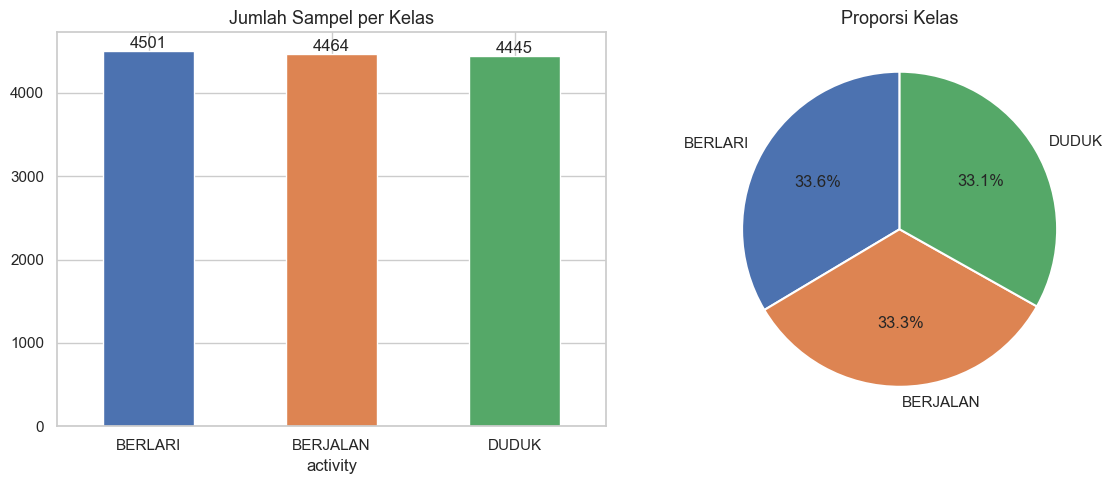

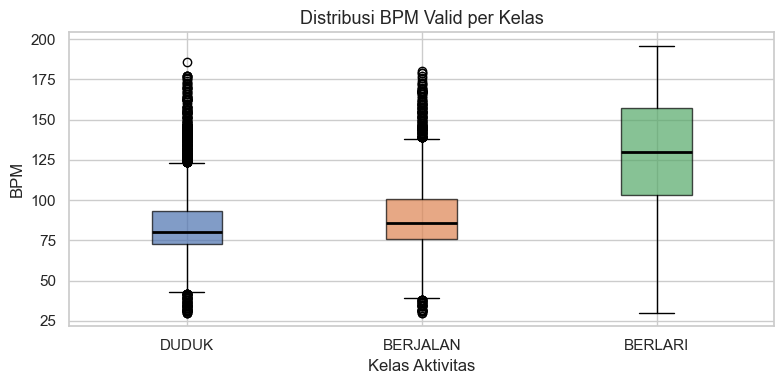

In [4]:
dist = class_distribution(df)
print('=== DISTRIBUSI KELAS ===')
print(dist.to_string())

# Statistik BPM per kelas (ditampilkan bersama distribusi kelas)
print('\n=== STATISTIK BPM per KELAS ===')
print(f'{"Kelas":<12} {"N":>6} {"BPM=0":>8} {"% Valid":>9} {"Mean BPM":>10} {"Median":>8} {"Min":>6} {"Max":>6}')
print('─' * 68)
for cls in CLASSES:
    sub    = df[df[TARGET] == cls]
    valid  = sub[sub['bpm'] > 0]['bpm']
    pct    = len(valid) / len(sub) * 100
    mean_b = valid.mean() if len(valid) > 0 else 0
    med_b  = valid.median() if len(valid) > 0 else 0
    mn_b   = valid.min()    if len(valid) > 0 else 0
    mx_b   = valid.max()    if len(valid) > 0 else 0
    print(f'{cls:<12} {len(sub):>6} {len(sub)-len(valid):>8} {pct:>8.1f}% '
          f'{mean_b:>10.1f} {med_b:>8.0f} {mn_b:>6.0f} {mx_b:>6.0f}')

# Grafik: bar + pie distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dist['count'].plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white', rot=0)
axes[0].set_title('Jumlah Sampel per Kelas', fontsize=13)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom')
axes[1].pie(dist['count'], labels=dist.index, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporsi Kelas', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/distribusi_kelas.png', dpi=150)
plt.show()

# Grafik BPM valid per kelas (boxplot)
fig2, ax = plt.subplots(figsize=(8, 4))
data_bpm = [df[(df[TARGET]==cls) & (df['bpm']>0)]['bpm'].values for cls in CLASSES]
bp = ax.boxplot(data_bpm, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(CLASSES)+1)); ax.set_xticklabels(CLASSES)
ax.set_title('Distribusi BPM Valid per Kelas', fontsize=13)
ax.set_ylabel('BPM')
ax.set_xlabel('Kelas Aktivitas')
plt.tight_layout()
plt.savefig('../data/processed/distribusi_bpm_per_kelas.png', dpi=150)
plt.show()


## 4. Distribusi Ketiga Fitur per Kelas (Accel + Gyro + BPM)

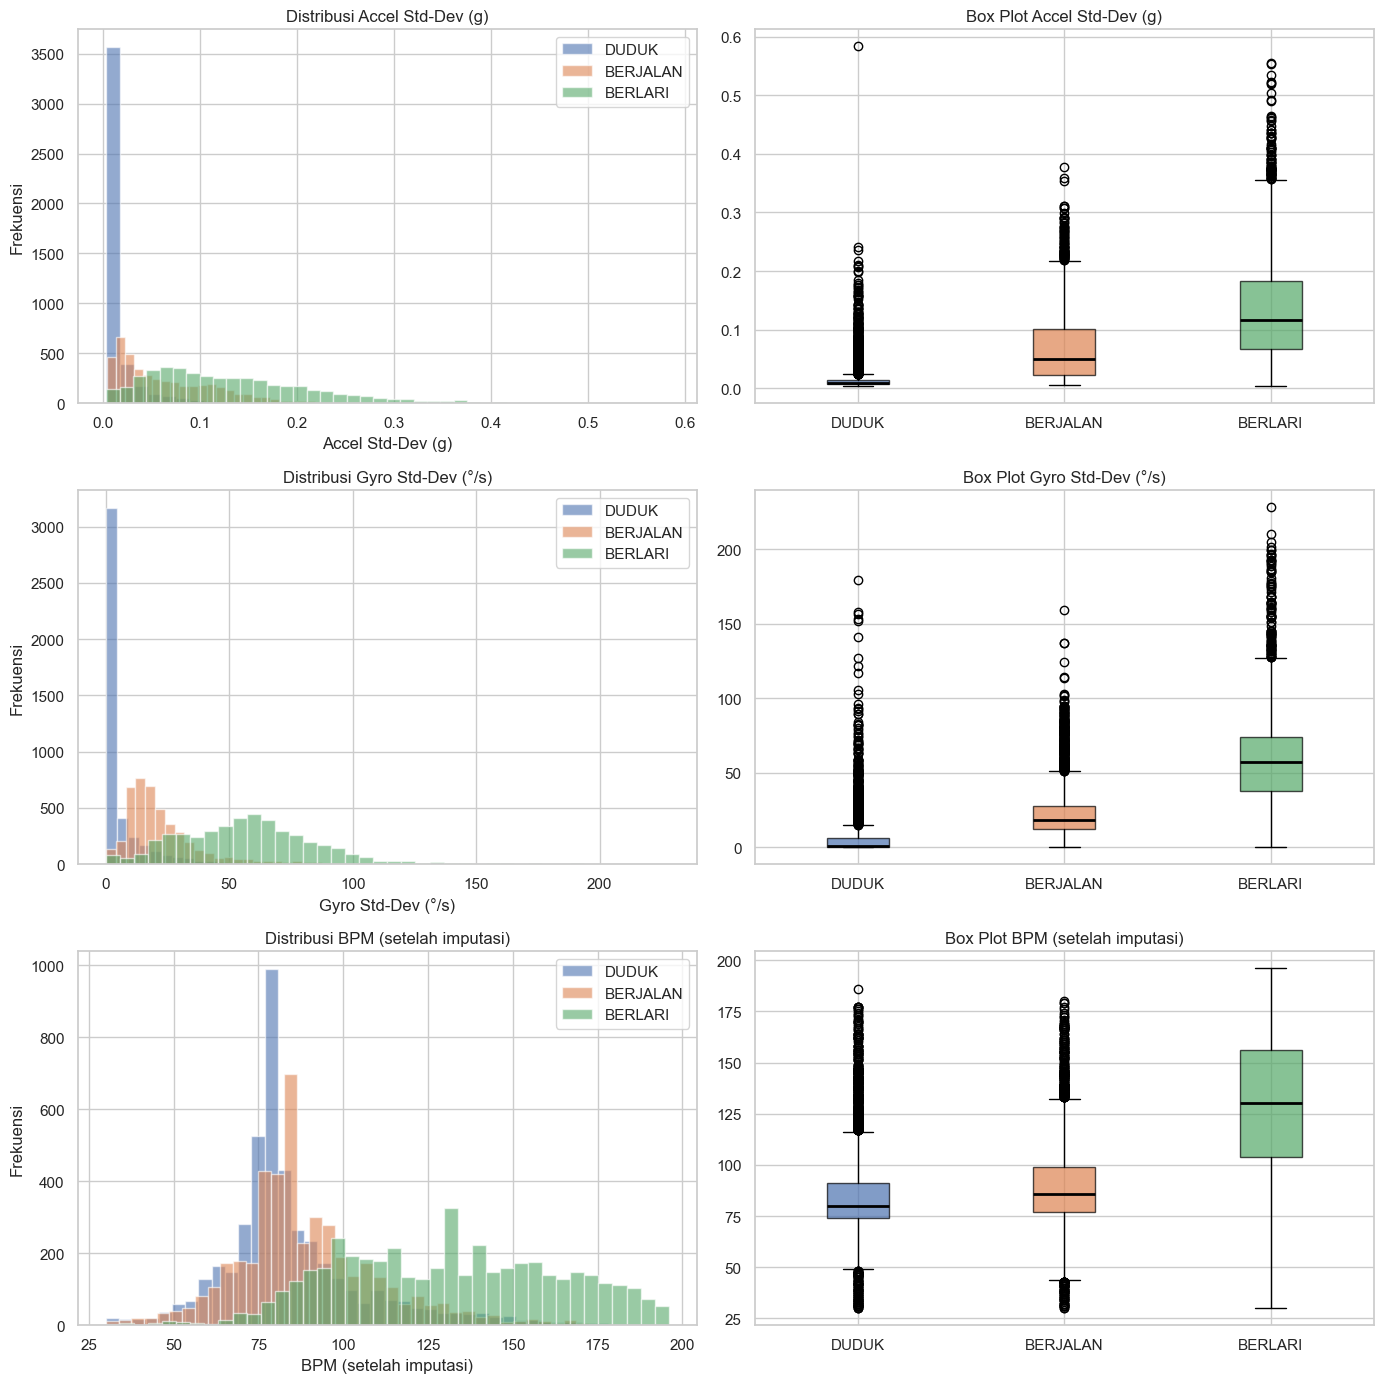

In [5]:
feat_labels = {
    'accel_stddev': 'Accel Std-Dev (g)',
    'gyro_stddev':  'Gyro Std-Dev (°/s)',
    'bpm_filled':   'BPM (setelah imputasi)'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
color_map = dict(zip(CLASSES, COLORS))

for row_idx, feat in enumerate(['accel_stddev', 'gyro_stddev', 'bpm_filled']):
    label = feat_labels[feat]
    # Histogram
    ax = axes[row_idx][0]
    for cls in CLASSES:
        subset = df[df[TARGET]==cls][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color_map[cls], label=cls)
    ax.set_title(f'Distribusi {label}', fontsize=12)
    ax.set_xlabel(label); ax.set_ylabel('Frekuensi'); ax.legend()
    # Box plot
    ax2 = axes[row_idx][1]
    data_per = [df[df[TARGET]==cls][feat].values for cls in CLASSES]
    bp = ax2.boxplot(data_per, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax2.set_xticks(range(1, len(CLASSES)+1)); ax2.set_xticklabels(CLASSES)
    ax2.set_title(f'Box Plot {label}', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/distribusi_3fitur.png', dpi=150)
plt.show()

## 5. Scatter Matrix 3D — Separabilitas Kelas

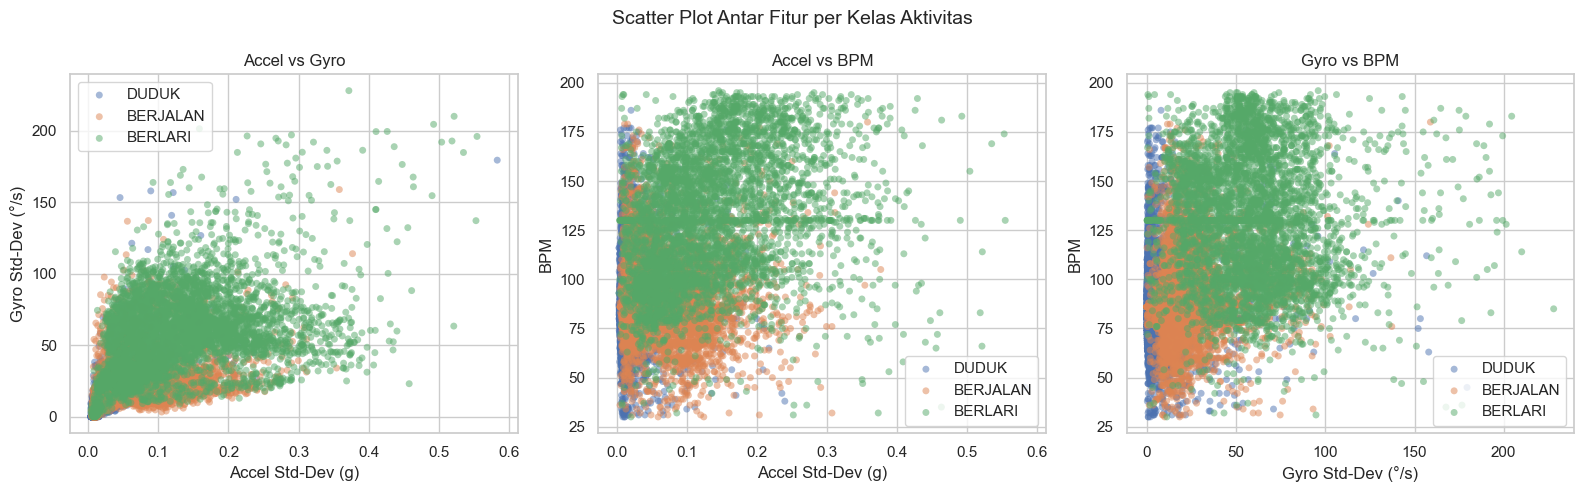

In [6]:
fig = plt.figure(figsize=(16, 5))

# Plot 1: Accel vs Gyro
ax1 = fig.add_subplot(131)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax1.scatter(s['accel_stddev'], s['gyro_stddev'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax1.set_xlabel('Accel Std-Dev (g)'); ax1.set_ylabel('Gyro Std-Dev (°/s)')
ax1.set_title('Accel vs Gyro'); ax1.legend()

# Plot 2: Accel vs BPM
ax2 = fig.add_subplot(132)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax2.scatter(s['accel_stddev'], s['bpm_filled'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax2.set_xlabel('Accel Std-Dev (g)'); ax2.set_ylabel('BPM')
ax2.set_title('Accel vs BPM'); ax2.legend()

# Plot 3: Gyro vs BPM
ax3 = fig.add_subplot(133)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax3.scatter(s['gyro_stddev'], s['bpm_filled'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax3.set_xlabel('Gyro Std-Dev (°/s)'); ax3.set_ylabel('BPM')
ax3.set_title('Gyro vs BPM'); ax3.legend()

plt.suptitle('Scatter Plot Antar Fitur per Kelas Aktivitas', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/scatter_3fitur.png', dpi=150)
plt.show()

## 6. Statistik Per Kelas — Panduan Tuning Threshold ESP32

In [7]:
print('=== STATISTIK PER KELAS ===')
for feat, label in feat_labels.items():
    print(f'\n  {feat} ({label}):')
    for cls in CLASSES:
        s = df[df[TARGET]==cls][feat]
        print(f'    {cls:<10}: mean={s.mean():.4f}  std={s.std():.4f}  '
              f'p5={s.quantile(0.05):.4f}  p95={s.quantile(0.95):.4f}')

=== STATISTIK PER KELAS ===

  accel_stddev (Accel Std-Dev (g)):
    DUDUK     : mean=0.0169  std=0.0239  p5=0.0055  p95=0.0608
    BERJALAN  : mean=0.0669  std=0.0542  p5=0.0104  p95=0.1690
    BERLARI   : mean=0.1331  std=0.0859  p5=0.0258  p95=0.2964

  gyro_stddev (Gyro Std-Dev (°/s)):
    DUDUK     : mean=6.2755  std=13.1614  p5=0.1431  p95=30.2494
    BERJALAN  : mean=22.7992  std=16.6687  p5=6.0326  p95=58.1281
    BERLARI   : mean=58.1749  std=29.2653  p5=17.1944  p95=104.9952

  bpm_filled (BPM (setelah imputasi)):
    DUDUK     : mean=84.6351  std=21.6704  p5=57.0000  p95=131.0000
    BERJALAN  : mean=89.1714  std=21.8087  p5=58.0000  p95=131.0000
    BERLARI   : mean=130.4901  std=32.3947  p5=81.0000  p95=184.0000


## 7. Analisis BPM — Distribusi Valid vs Imputasi

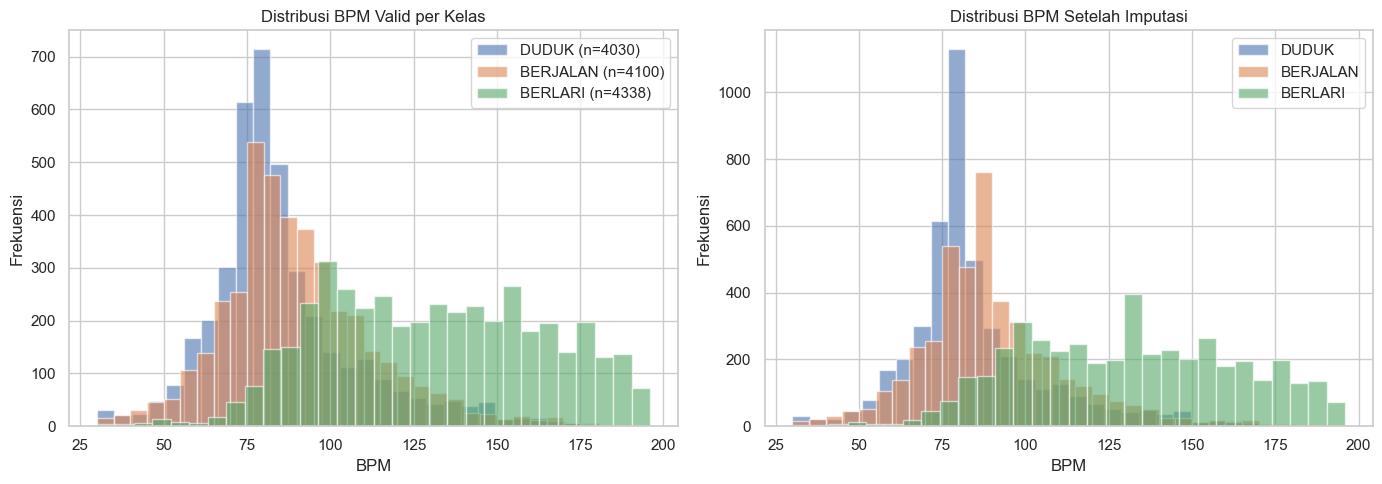


=== % BPM Valid per Kelas ===
  DUDUK     : 4030/4445 (90.7% valid)
  BERJALAN  : 4100/4464 (91.8% valid)
  BERLARI   : 4338/4501 (96.4% valid)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BPM valid saja per kelas
ax = axes[0]
for cls, color in zip(CLASSES, COLORS):
    valid = df_raw[(df_raw[TARGET]==cls) & (df_raw['bpm']>0)]['bpm']
    ax.hist(valid, bins=30, alpha=0.6, color=color, label=f'{cls} (n={len(valid)})')
ax.set_title('Distribusi BPM Valid per Kelas', fontsize=12)
ax.set_xlabel('BPM'); ax.set_ylabel('Frekuensi'); ax.legend()

# BPM setelah imputasi per kelas
ax2 = axes[1]
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]['bpm_filled']
    ax2.hist(s, bins=30, alpha=0.6, color=color, label=cls)
ax2.set_title('Distribusi BPM Setelah Imputasi', fontsize=12)
ax2.set_xlabel('BPM'); ax2.set_ylabel('Frekuensi'); ax2.legend()

plt.tight_layout()
plt.savefig('../data/processed/bpm_distribusi.png', dpi=150)
plt.show()

# Persentase BPM valid
print('\n=== % BPM Valid per Kelas ===')
for cls in CLASSES:
    total = len(df_raw[df_raw[TARGET]==cls])
    valid = len(df_raw[(df_raw[TARGET]==cls)&(df_raw['bpm']>0)])
    print(f'  {cls:<10}: {valid:4d}/{total:4d} ({valid/total*100:.1f}% valid)')

## 8. Deteksi Outlier & Simpan Dataset Bersih

In [9]:
from utils import remove_outliers
df_clean = remove_outliers(df)
print(f'Sebelum remove outlier: {len(df)}')
print(f'Sesudah remove outlier: {len(df_clean)}')
print(f'Dihapus: {len(df)-len(df_clean)} baris')

clean_path = '../data/processed/dataset_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'\n✅ Dataset bersih disimpan → {clean_path}')
print(f'   Shape: {df_clean.shape}')

Sebelum remove outlier: 13410
Sesudah remove outlier: 13214
Dihapus: 196 baris

✅ Dataset bersih disimpan → ../data/processed/dataset_clean.csv
   Shape: (13214, 8)


## 9. Korelasi Fitur

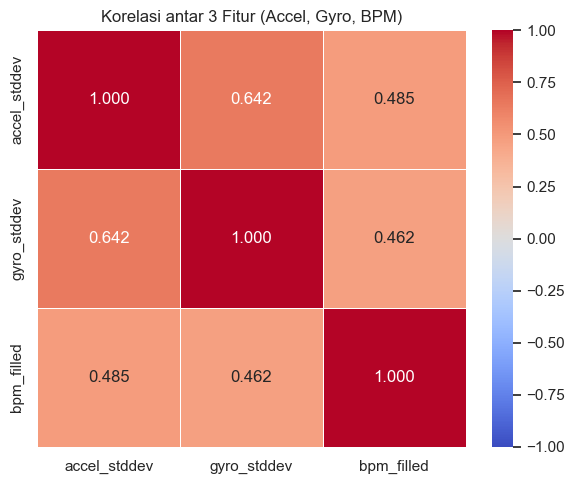

In [10]:
corr_cols = ['accel_stddev','gyro_stddev','bpm_filled']
corr = df_clean[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korelasi antar 3 Fitur (Accel, Gyro, BPM)')
plt.tight_layout()
plt.savefig('../data/processed/korelasi_3fitur.png', dpi=150)
plt.show()